In [18]:
import pandas as pd
import numpy as np
import re
import os
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import pandas as pd
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import matplotlib.pyplot as plt
import scipy.stats as stats


In [19]:
full_data = pd.read_csv("data_panel/full_panel_master.csv")
print(full_data)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu    hicp  log_prod  \
0          102.25  55.82             36.58      3

In [20]:
full_data = full_data.rename(columns={'log_wage' : 'log_wage_ij', 
                                      'tert_edu' : 'educ_ij',
                                      'log_hicp' : 'log_hicp_i', 
                                      'log_prod' : 'log_prdct_ij', 
                                      'share_high_skill' : 'h_skill_ij', 
                                      'unempl_r' : 'unempl_r_i', 
                                      'infl_r' : 'infl_r_i', 
                                      'log_gdp' : 'log_gdp_i', 
                                      'FSI' : 'fsi_ij',
                                      'ai_adoption' : 'ai_ij',
                                      'spec_ict' : 'ict_spec_ij', 
                                      'training_ict' : 'ict_tr_ij'})

print(full_data)

    geo nace_r2  real_wage  year   ai_ij  ict_spec_ij  ict_tr_ij  \
0    AT       C      26.74  2021   9.610        28.56      22.98   
1    AT       C      26.18  2022  10.960        28.37      25.60   
2    AT       C      26.07  2023  12.310        29.20      25.83   
3    AT       C      27.05  2024  22.710        30.02      26.06   
4    AT       F      22.43  2021   3.120         8.64       8.28   
..   ..     ...        ...   ...     ...          ...        ...   
531  SK       G       8.45  2024  11.650        15.19      19.87   
532  SK       J      15.69  2021  18.190        70.76      55.96   
533  SK       J      14.79  2022  19.905        71.88      53.54   
534  SK       J      14.48  2023  21.620        70.80      58.16   
535  SK       J      14.67  2024  29.190        69.72      62.79   

     productivity  fsi_ij  h_skill_ij  educ_ij    hicp  log_prdct_ij  \
0          102.25   55.82       36.58     31.8  111.46          4.63   
1          108.40   56.10       37.32  

In [21]:
duplicates = full_data[full_data.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [geo, nace_r2, real_wage, year, ai_ij, ict_spec_ij, ict_tr_ij, productivity, fsi_ij, h_skill_ij, educ_ij, hicp, log_prdct_ij, log_wage_ij, log_hicp_i, unempl_r_i, infl_r_i, gdp, log_gdp_i]
Index: []


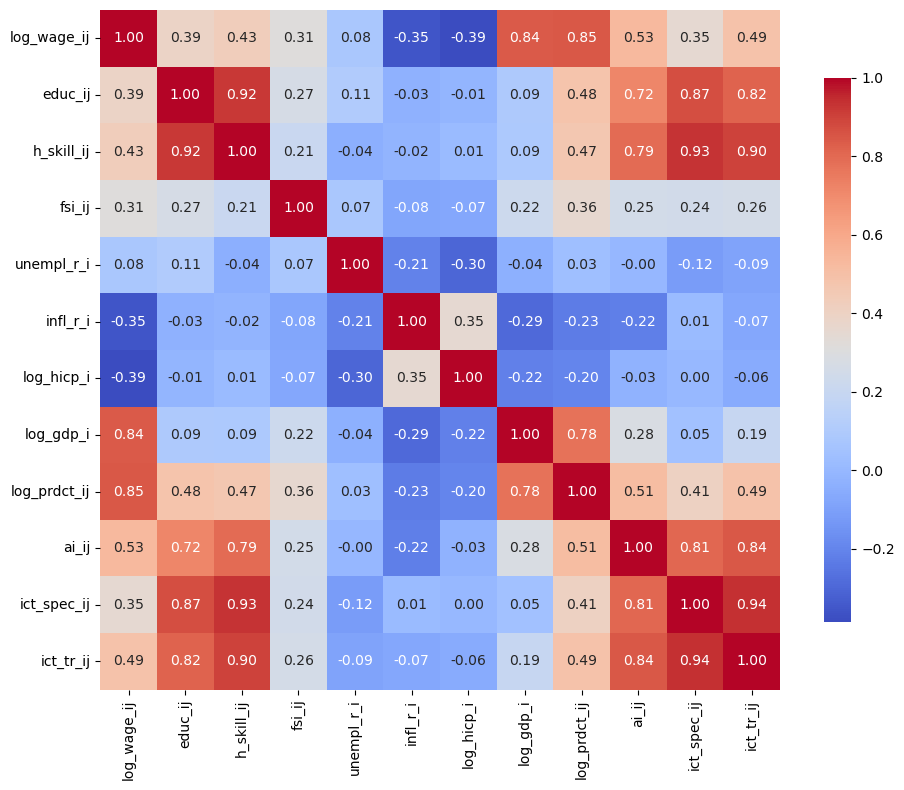

In [6]:
# Choose variables for the matrix
cols = [
    "log_wage_ij", "educ_ij", "h_skill_ij", "fsi_ij", "unempl_r_i", "infl_r_i", 
    "log_hicp_i", "log_gdp_i", "log_prdct_ij", "ai_ij", "ict_spec_ij", "ict_tr_ij"
]

corr = full_data[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()


In [7]:
print(corr)

              log_wage_ij   educ_ij  h_skill_ij    fsi_ij  unempl_r_i  \
log_wage_ij      1.000000  0.391919    0.429491  0.313104    0.077938   
educ_ij          0.391919  1.000000    0.920435  0.268441    0.106239   
h_skill_ij       0.429491  0.920435    1.000000  0.207809   -0.040501   
fsi_ij           0.313104  0.268441    0.207809  1.000000    0.074365   
unempl_r_i       0.077938  0.106239   -0.040501  0.074365    1.000000   
infl_r_i        -0.353831 -0.030478   -0.018089 -0.082018   -0.211670   
log_hicp_i      -0.386154 -0.014578    0.011221 -0.073711   -0.302671   
log_gdp_i        0.838540  0.094917    0.090271  0.220581   -0.039134   
log_prdct_ij     0.846740  0.480259    0.468433  0.356481    0.031331   
ai_ij            0.532991  0.715673    0.794594  0.250067   -0.002673   
ict_spec_ij      0.350511  0.872463    0.933833  0.244436   -0.117507   
ict_tr_ij        0.486636  0.816345    0.898823  0.257359   -0.089570   

              infl_r_i  log_hicp_i  log_gdp_i  log

# UPDATED DATASET FOR THE 2021-2024

In [22]:
data_24 = full_data[full_data['year'] == 2024]
data_23 = full_data[full_data['year'] == 2023]
data_22 = full_data[full_data['year'] == 2022]
data_21 = full_data[full_data['year'] == 2021]

#### 2021

##### Baseline models

In [23]:
model_1 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           7.56e-70
Time:                        00:11:45   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4919      0.038    -

In [24]:
def models_diagnostic(model): 
    print(f"DIAGNOSTIC TESTS")

    # 1. Breusch-Pagan Test for Heteroskedasticity
    name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
    test = sms.het_breuschpagan(model.resid, model.model.exog)
    print(f"\nBreusch-Pagan Test:\n{lzip(name, test)}")
    if test[1] < 0.05:
        print(">> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').")
    else:
        print(">> RESULT: Homoskedasticity (Variance is constant).")

    # 2. Ramsey RESET Test (Linearity)
    # power=2 means checking for squared terms
    reset_test = sms.linear_reset(model, power=2, test_type='fitted', use_f=True)
    print(f"\nRamsey RESET Test:\n{reset_test}")

    # # VISUAL CHECKS
    # fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # # Plot 1: Residuals vs Fitted (Check for patterns/heteroskedasticity visually)
    # ax[0].scatter(model.fittedvalues, model.resid)
    # ax[0].axhline(0, color='red', linestyle='--')
    # ax[0].set_xlabel("Fitted Values")
    # ax[0].set_ylabel("Residuals")
    # ax[0].set_title("Residuals vs Fitted")

    # # Plot 2: Q-Q Plot (Check Normality)
    # stats.probplot(model.resid, dist="norm", plot=ax[1])
    # ax[1].set_title("Q-Q Plot")

    # plt.show()

models_diagnostic(model_1)    

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353698), ('p-value', 0.013777804040877478), ('f-value', 2.2504818397508357), ('f p-value', 0.0009533215868131954)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500561727, p=7.661498978323216e-08, df_denom=97, df_num=1>


In [ ]:
model_2 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    data=data_21
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     179.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.05e-62
Time:                        18:12:10   Log-Likelihood:                 39.728
No. Observations:                 134   AIC:                            -63.46
Df Residuals:                     126   BIC:                            -40.27
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.5685      0.466    -11.948   

In [11]:
models_diagnostic(model_2)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 46.8780889402053), ('p-value', 5.896116418985454e-08), ('f-value', 9.685343108974772), ('f p-value', 1.313002661199944e-09)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.336482313974145, p=0.00023621535379415138, df_denom=125, df_num=1>


In [ ]:
model_3 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.56e-70
Time:                        18:12:14   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.0733      0.144     

In [13]:
models_diagnostic(model_3)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353835), ('p-value', 0.010419906748429936), ('f-value', 2.2504818397509285), ('f p-value', 0.0009533215868126768)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500560399, p=7.661498978361927e-08, df_denom=97, df_num=1>


In [ ]:
model_4 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    data=data_21
).fit()

print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     86.75
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.64e-42
Time:                        18:12:21   Log-Likelihood:                -11.752
No. Observations:                 134   AIC:                             37.50
Df Residuals:                     127   BIC:                             57.79
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.2230      0.212     -1.051   

In [15]:
models_diagnostic(model_4)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 36.109024480396094), ('p-value', 2.625337555631053e-06), ('f-value', 7.807744082415322), ('f p-value', 3.657989498510418e-07)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=40.15973346683762, p=3.7967409301215315e-09, df_denom=126, df_num=1>


In [ ]:
model_5 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    data=data_21
).fit()

print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.56e-70
Time:                        18:12:24   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5299      0.192     

In [17]:
models_diagnostic(model_5)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 59.71005858353525), ('p-value', 0.005729153601985556), ('f-value', 2.250481839750719), ('f p-value', 0.0009533215868138549)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=33.84907500561692, p=7.66149897832419e-08, df_denom=97, df_num=1>


In [19]:
model_6 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",
    data=data_21
).fit()

print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     117.5
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           5.07e-42
Time:                        18:13:10   Log-Likelihood:                -18.025
No. Observations:                 134   AIC:                             46.05
Df Residuals:                     129   BIC:                             60.54
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5587      0.157     -3.551   

In [20]:
models_diagnostic(model_6)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 24.964876733830163), ('p-value', 5.113453844072434e-05), ('f-value', 7.384017649988066), ('f p-value', 2.1841105175225604e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=36.9488968526825, p=1.2958008085515662e-08, df_denom=128, df_num=1>


In [21]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_1, model_2,model_3, model_4, model_5, model_6],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(1) Baseline', '(2) Baseline (no FE)', '(3) Baseline (GDP excl) ', '(4) Baseline (no FE, GDP excl)', '(5) No macro controls', '(6) No macro controls (no FE)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)
print(results_table)


                (1) Baseline (2) Baseline (no FE) (3) Baseline (GDP excl)  (4) Baseline (no FE, GDP excl) (5) No macro controls (6) No macro controls (no FE)
-------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept       -0.492***    -5.569***            2.073***                 -0.223                         2.530***              -0.559***                    
                (0.038)      (0.466)              (0.144)                  (0.212)                        (0.192)               (0.157)                      
C(geo)[T.BE]    0.105                             0.004                                                   0.004                                              
                (0.065)                           (0.066)                                                 (0.067)                                            
C(geo)[T.BG]    -0.814***                         -

1. The "Education vs. Skills" Puzzle (Measurement Matter)
Observation: In Model 2 and 4 (No Country FE), h_skill_ij (High Skill Occupation) is highly significant and positive ($0.012^{}$), while educ_ij (Tertiary Education) is significant but negative ($-0.007^{}$ or $-0.011^{***}$).

Conclusion: Occupational structure matters more than formal education degrees. Once the control for productivity and the specific job type (high-skill occupation), simply having a degree doesn't automatically raise wages—in fact, it might capture some over-education effects or sectoral composition issues. This supports focusing on active skill measures (like  ICT training variable later) rather than just static educational attainment.

2. The Dominance of Country Heterogeneity (R-squared Gap)
Observation:

Model 4 (No Country FE, GDP Excl): $R^2 = 0.804$

Model 3 (Country FE, GDP Excl): $R^2 = 0.981$

Conclusion: Country-specific factors explain ~18% of the variation that sector and productivity alone cannot. This confirms that any analysis without Country FE (or strong country controls like HICP/GDP) risks Omitted Variable Bias. The fact that $R^2$ jumps so high suggests that national wage setting institutions (unions, minimum wages, price levels) are massive drivers of the wage level.

3. The "Macro Instability" (be careful)
Observation: Look at the coefficient for log_prdct_ij (Productivity).

In Model 4 (No FE): It is 0.782* (Very high, close to 1:1).

In Model 3 (With FE): It drops to 0.075*.

Conclusion: Most of the "productivity-wage" link is actually a cross-country phenomenon, not a within-sector one. Rich countries have high productivity and high wages (Model 4). But within a specific country (Model 3), being a slightly more productive sector only yields a small wage premium ($0.075$).

Implication for the Hypothesis: If AI increases productivity, don't expect it to double wages overnight. The "within-country" transmission channel is stiff.

4. Firm Size is a Weak Predictor
Observation: fsi_ij is only marginally significant ($0.002^{*}$) in FE models and insignificant ($0.000$) in others.

Conclusion: Unlike productivity or skills, simply being in a sector with large firms doesn't guarantee higher wages once we control for the other factors. This allows ud to treat fsi as a minor control rather than a major driver.



MODELS TEST RESULTS: 
Heteroskedasticity is Universal (Breusch-Pagan Test)
In every single model (1 through 6), the Breusch-Pagan test returns a p-value $< 0.05$ (often $< 0.001$).

Our error terms do not have constant variance. This is expected in cross-country wage data (large countries like Germany have different variance than small ones like Malta).
We must use robust standard errors in all our final regressions.

In statsmodels, add .fit(cov_type='HC3') (or 'HC1').

Note: This will correct our t-statistics and p-values. It won't change the coefficients, but it makes our inference valid.

2. Functional Form Misspecification (Ramsey RESET Test)
Result: In every single model, the Ramsey RESET test is highly significant ($p < 0.001$).

Interpretation: The model is "misspecified" in its linear form. This means the relationship between our variables isn't a simple straight line ($y = ax + b$).This strongly supports our hypothesis that interaction terms (moderation) are needed. The RESET test detects if squared terms or interactions are missing.

Since the linear models fail this test, it statistically justifies adding the $AI \times ICT$ interaction terms we planned. You can explicitly say: "The Ramsey RESET test rejected the linear specification, motivating the inclusion of interaction terms to capture non-linear moderation effects."

3. Normality is "Acceptable" (Jarque-Bera)
Result:

Models 1, 3, 5 (With FE): Jarque-Bera p-value $\approx 0.15$ (Do not reject Normality). The residuals are normal.

Models 2, 4, 6 (No FE): Jarque-Bera p-value $< 0.05$ (Reject Normality).

The Fixed Effects models (1, 3, 5) fit the data distribution much better. The non-FE models leave behind some skewness (likely because they fail to account for the specific wage structures of different countries).

We need to rely more on the FE models (1, 3, 5) for inference, as their residuals satisfy the normality assumption better.

4. Multicollinearity Warning (Condition Number)
Result:

Models 1, 3, 5 (With FE): Condition Number is massive ($10^{16}$ or $10^{17}$).

Models 2, 4, 6 (No FE): Condition Number is moderate ($500 - 2000$).

Interpretation: The massive condition number in the FE models confirms the "perfect collinearity" we discussed (Country Dummies vs. Macro variables). Python handles this by effectively dropping the collinear macro variables behind the scenes (or making their SEs huge), but it's a signal that we should typically drop the explicit macro variables (Inflation, Unemployment) when using Country FE to clean up the math.

In [23]:
formulas = [
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    "log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)
--------------------------------------------------
        feature       VIF
   C(geo)[T.NO]       inf
   C(geo)[T.LT]       inf
       infl_r_i       inf
     unempl_r_i       inf
   C(geo)[T.SK]       inf
   C(geo)[T.SI]       inf
   C(geo)[T.SE]       inf
   C(geo)[T.RO]       inf
   C(geo)[T.PT]       inf
   C(geo)[T.PL]       inf
   C(geo)[T.BE]       inf
   C(geo)[T.NL]       inf
   C(geo)[T.MT]       inf
   C(geo)[T.LV]       inf
      log_gdp_i       inf
   C(geo)[T.IT]       inf
   C(geo)[T.EE]       inf
   C(geo)[T.BG]       inf
   C(geo)[T.IE]       inf
   C(geo)[T.CY]       inf
   C(geo)[T.DE]       inf
   C(geo)[T.DK]       inf
   C(geo)[T.CZ]       inf
   C(geo)[T.ES]       inf
   C(geo)[T.FI]       inf
   C(geo)[T.FR]       inf
   C(geo)[T.HR]       inf
   C(geo)[T.HU]       inf
     h_skill_ij 66.228675
        educ_ij 3

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


The "Perfect Collinearity" of Country FE and Macro Controls (Models 1 & 3). This confirms mathematically that we cannot include country-level macro variables and Country Fixed Effects in the same cross-sectional model.

The "Skill Cluster" Explosion (Models 1, 3, 5): 

- h_skill_ij: VIF ~ 66.2

- educ_ij: VIF ~ 37.2

- C(nace_r2)[T.J]: VIF ~ 27.2

This is dangerously high (Rule of thumb: VIF > 10 is problematic). It means the model cannot tell the difference between "High Skill Occupation," "Tertiary Education," and "The Tech Sector (J)." Sector J (Information/Communication) is almost purely defined by high-skill, high-education workers. By putting all three in, we are asking the model: "What is the effect of being in the Tech sector, holding education and skill constant?" But we can't hold them constant because they are defining features of the sector.
We could think about dropping educ_ij. h_skill_ij (Occupational skill) usually has a more direct link to wages. Or, drop both if we are including Sector FE and want to focus purely on AI/ICT as the "new" skill variable. We need to use precisely educ_ij and h_skill_variable.

Productivity-GDP: When we remove GDP (Model 4), the VIF for log_prdct_ij drops to 1.6. This is much cleaner. It suggests that without GDP, "Productivity" captures both the sector's efficiency and the country's development level. 

##### Include AI and ICT variables 

In [24]:
model_7 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
    data=data_21
).fit(cov_type='HC3')

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     142.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.56e-70
Time:                        18:14:17   Log-Likelihood:                 143.87
No. Observations:                 134   AIC:                            -215.7
Df Residuals:                      98   BIC:                            -111.4
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4919      0.038    -

In [25]:
models_diagnostic(model_7)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.11656093060196), ('p-value', 0.01120883922446168), ('f-value', 2.063583920945766), ('f p-value', 0.002701988212348333)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.63567316434395, p=4.540089177217049e-06, df_denom=96, df_num=1>


In [28]:
model_8 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",
    data=data_21
).fit(cov_type='HC3')

print(model_8.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     170.4
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.01e-63
Time:                        18:14:38   Log-Likelihood:                 42.754
No. Observations:                 134   AIC:                            -67.51
Df Residuals:                     125   BIC:                            -41.43
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.3592      0.505    -10.615   

In [27]:
models_diagnostic(model_7)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.11656093060196), ('p-value', 0.01120883922446168), ('f-value', 2.063583920945766), ('f p-value', 0.002701988212348333)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=23.63567316434395, p=4.540089177217049e-06, df_denom=96, df_num=1>


In [29]:
model_9 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)", # educ_ij
    data=data_21
).fit(cov_type='HC3')

print(model_9.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     208.3
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.06e-77
Time:                        18:14:42   Log-Likelihood:                 142.47
No. Observations:                 134   AIC:                            -212.9
Df Residuals:                      98   BIC:                            -108.6
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.3990      0.297     

In [30]:
models_diagnostic(model_9)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.192385363199904), ('p-value', 0.008208613093016789), ('f-value', 2.1493708751767353), ('f p-value', 0.001727747935892968)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=31.401285301347244, p=1.9652360715521728e-07, df_denom=97, df_num=1>


In [31]:
model_10 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)", # educ_ij +
    data=data_21
).fit(cov_type='HC3')

print(model_10.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     211.7
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.13e-77
Time:                        18:14:46   Log-Likelihood:                 151.10
No. Observations:                 134   AIC:                            -228.2
Df Residuals:                      97   BIC:                            -121.0
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [32]:
models_diagnostic(model_10)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 65.32140121802294), ('p-value', 0.001987312929098085), ('f-value', 2.562732637775022), ('f p-value', 0.00013739493068239703)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=24.473067981886306, p=3.207254143482531e-06, df_denom=96, df_num=1>


In [33]:
model_11 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)", # h_skill_ij +
    data=data_21
).fit(cov_type='HC3')

print(model_11.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     232.7
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           5.08e-80
Time:                        18:14:53   Log-Likelihood:                 145.43
No. Observations:                 134   AIC:                            -218.9
Df Residuals:                      98   BIC:                            -114.5
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4612      0.282     

In [34]:
models_diagnostic(model_11)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 58.633544369528636), ('p-value', 0.007400900000003961), ('f-value', 2.178342113361944), ('f p-value', 0.001457840314804161)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=29.547089288327125, p=4.0655241549149417e-07, df_denom=97, df_num=1>


In [35]:
model_12 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)", # h_skill_ij +
    data=data_21
).fit(cov_type='HC3')

print(model_12.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     242.4
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.77e-80
Time:                        18:15:03   Log-Likelihood:                 155.94
No. Observations:                 134   AIC:                            -237.9
Df Residuals:                      97   BIC:                            -130.7
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.6158 

In [36]:
models_diagnostic(model_12)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 65.50184365686151), ('p-value', 0.001898404650770022), ('f-value', 2.576581446338129), ('f p-value', 0.00012640071669131966)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=22.02816950759943, p=8.919148633390406e-06, df_denom=96, df_num=1>


In [37]:
def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_7, model_8, model_9, model_10, model_11, model_12], # model_13, model_14, model_15, model_16, model_delta_tr, model_delta_spec
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(7)', '(8)', '(9)', '(10)', '(11)', '(12)'], # '(13)', '(14)', '(15)', '(16)', '(17)', '(18)'
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                          (7)       (8)       (9)       (10)      (11)      (12)  
----------------------------------------------------------------------------------
Intercept              2.582***  -5.359*** 2.399***  2.538***  2.461***  2.616*** 
                       (0.274)   (0.505)   (0.297)   (0.263)   (0.282)   (0.241)  
C(nace_r2)[T.F]        0.039               0.053     0.062     0.034     0.034    
                       (0.078)             (0.086)   (0.084)   (0.078)   (0.073)  
C(nace_r2)[T.G]        -0.038              -0.020    -0.034    -0.044    -0.058*  
                       (0.037)             (0.040)   (0.036)   (0.039)   (0.034)  
C(nace_r2)[T.H]        -0.054              -0.046    -0.037    -0.042    -0.036   
                       (0.052)             (0.045)   (0.042)   (0.043)   (0.041)  
C(nace_r2)[T.I]        -0.197**            -0.156    -0.159*   -0.170*   -0.181** 
                       (0.087)             (0.103)   (0.091)   (0.097)   (0.083)  
C(n

In [39]:
formulas = [
"log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
"log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",

"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 535.443658
     h_skill_ij  66.229674
        educ_ij  37.302126
C(nace_r2)[T.J]  30.487144
   log_prdct_ij  10.819290
          ai_ij   8.610570
C(nace_r2)[T.F]   6.897732
         fsi_ij   6.773421
   C(geo)[T.ES]   3.884771
   C(geo)[T.BG]   3.764718
   C(geo)[T.HU]   3.659567
   C(geo)[T.LT]   3.655966
   C(geo)[T.DK]   3.593838
   C(geo)[T.PL]   3.555792
   C(geo)[T.HR]   3.236118
   C(geo)[T.CZ]   3.233572
   C(geo)[T.RO]   3.218463
   C(geo)[T.CY]   3.176068
   C(geo)[T.EE]   3.106025
   C(geo)[T.LV]   3.104404
C(nace_r2)[T.I]   3.079019
C(nace_r2)[T.N]   2.951462
   C(geo)[T.IE]   2.908101
   C(geo)[T.IT]   2.757821
C(nace_r2)[T.G]   2.698345
   C(geo)[T.FR]   2.642187
   C(geo)[T.SI]   2.637490
C(nace_r2)[T.H]   2.602071
   C(geo)[T.SE]   2.439815
   C(geo)[T.NO

##### Marginal effects

In [41]:
print(model_10.params.index)

Index(['Intercept', 'C(nace_r2)[T.F]', 'C(nace_r2)[T.G]', 'C(nace_r2)[T.H]',
       'C(nace_r2)[T.I]', 'C(nace_r2)[T.J]', 'C(nace_r2)[T.N]', 'C(geo)[T.BE]',
       'C(geo)[T.BG]', 'C(geo)[T.CY]', 'C(geo)[T.CZ]', 'C(geo)[T.DE]',
       'C(geo)[T.DK]', 'C(geo)[T.EE]', 'C(geo)[T.ES]', 'C(geo)[T.FI]',
       'C(geo)[T.FR]', 'C(geo)[T.HR]', 'C(geo)[T.HU]', 'C(geo)[T.IE]',
       'C(geo)[T.IT]', 'C(geo)[T.LT]', 'C(geo)[T.LV]', 'C(geo)[T.MT]',
       'C(geo)[T.NL]', 'C(geo)[T.NO]', 'C(geo)[T.PL]', 'C(geo)[T.PT]',
       'C(geo)[T.RO]', 'C(geo)[T.SE]', 'C(geo)[T.SI]', 'C(geo)[T.SK]',
       'log_prdct_ij', 'fsi_ij', 'ai_ij', 'ict_spec_ij',
       'I(ai_ij * ict_spec_ij)'],
      dtype='object')


In [44]:
# Model 10 
m10 = model_10

beta_ai = m10.params['ai_ij']
gamma_ai_ictspec = m10.params['I(ai_ij * ict_spec_ij)']

z = data_21['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high

print("Model 10 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


Model 10 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.46):  0.0059
  At mean ICT_spec (P50=17.89): 0.0048
  At high ICT_spec (P75=27.80): 0.0028


In [46]:
m12 = model_12
beta_ai = m12.params['ai_ij']
gamma_ai_icttr = m12.params['I(ai_ij * ict_tr_ij)']

z = data_21['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high

print("Model 12 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 12 – marginal effect of AI on log wage:
  At low ICT_tr (P25=13.09):  0.0082
  At mean ICT_tr (P50=18.83): 0.0066
  At high ICT_tr (P75=30.03): 0.0036


In [45]:
print(data_21['nace_r2'].unique())

['C' 'F' 'G' 'H' 'N' 'I' 'J']


#### 2022

In [49]:
model_13 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_13.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     197.0
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.57e-76
Time:                        19:06:39   Log-Likelihood:                 140.60
No. Observations:                 134   AIC:                            -209.2
Df Residuals:                      98   BIC:                            -104.9
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4582      0.319     

In [50]:
models_diagnostic(model_13)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 68.58388398717692), ('p-value', 0.00059090224479623), ('f-value', 2.9355896813936804), ('f p-value', 1.6109029309823067e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=26.4034633089355, p=1.4336976346299484e-06, df_denom=97, df_num=1>


In [52]:
model_14 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_14.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     222.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           9.79e-79
Time:                        19:07:19   Log-Likelihood:                 148.38
No. Observations:                 134   AIC:                            -222.8
Df Residuals:                      97   BIC:                            -115.5
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [54]:
models_diagnostic(model_14)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 72.50105444532329), ('p-value', 0.0002965166330729894), ('f-value', 3.1764782567350878), ('f p-value', 3.4776092807437815e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=22.170907044358863, p=8.396374968588428e-06, df_denom=96, df_num=1>


In [ ]:
model_15 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_15.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     218.7
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.01e-78
Time:                        19:07:24   Log-Likelihood:                 146.78
No. Observations:                 134   AIC:                            -221.6
Df Residuals:                      98   BIC:                            -117.2
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5203      0.291     

In [55]:
models_diagnostic(model_15)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 64.37493165671545), ('p-value', 0.0017956801363487075), ('f-value', 2.588863651093113), ('f p-value', 0.00012736709294128347)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=25.322360436457704, p=2.230391639106804e-06, df_denom=97, df_num=1>


In [56]:
model_16 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_22
).fit(cov_type='HC3')

print(model_16.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     237.5
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           4.77e-80
Time:                        19:08:33   Log-Likelihood:                 155.38
No. Observations:                 134   AIC:                            -236.8
Df Residuals:                      97   BIC:                            -129.5
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.6093 

In [57]:
models_diagnostic(model_16)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 66.40034181126296), ('p-value', 0.001509014914326169), ('f-value', 2.64664107624702), ('f p-value', 8.288905825897695e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=20.660279254639487, p=1.5983127318463954e-05, df_denom=96, df_num=1>


In [58]:
def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_13, model_14, model_15, model_16],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(13)', '(14)', '(15)', '(16)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                          (13)      (14)      (15)      (16)  
--------------------------------------------------------------
Intercept              2.458***  2.540***  2.520***  2.609*** 
                       (0.319)   (0.280)   (0.291)   (0.250)  
C(nace_r2)[T.F]        0.038     0.050     0.007     0.012    
                       (0.090)   (0.089)   (0.075)   (0.071)  
C(nace_r2)[T.G]        -0.025    -0.044    -0.062    -0.077** 
                       (0.041)   (0.037)   (0.041)   (0.035)  
C(nace_r2)[T.H]        -0.052    -0.039    -0.043    -0.035   
                       (0.047)   (0.045)   (0.043)   (0.042)  
C(nace_r2)[T.I]        -0.239**  -0.246*** -0.249*** -0.263***
                       (0.098)   (0.092)   (0.084)   (0.075)  
C(nace_r2)[T.J]        0.368*    0.320*    0.340***  0.280**  
                       (0.206)   (0.193)   (0.127)   (0.117)  
C(nace_r2)[T.N]        -0.214*** -0.235*** -0.215*** -0.239***
                       (0.044)   (0.040)   (0.039)   (

In [83]:
formulas = [

"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_22, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 487.989911
    ict_spec_ij  39.052348
C(nace_r2)[T.J]  28.217995
          ai_ij  12.198707
C(nace_r2)[T.F]   7.959787
   log_prdct_ij   7.442707
         fsi_ij   7.251708
   C(geo)[T.HU]   4.090716
   C(geo)[T.PL]   3.899216
   C(geo)[T.BG]   3.262362
C(nace_r2)[T.I]   3.206881
   C(geo)[T.RO]   3.183148
   C(geo)[T.HR]   3.027962
   C(geo)[T.CZ]   2.977260
   C(geo)[T.LV]   2.844851
   C(geo)[T.EE]   2.836903
   C(geo)[T.DK]   2.760368
   C(geo)[T.IE]   2.722161
   C(geo)[T.LT]   2.690451
   C(geo)[T.ES]   2.668482
C(nace_r2)[T.G]   2.647250
   C(geo)[T.IT]   2.618445
   C(geo)[T.FR]   2.577288
   C(geo)[T.CY]   2.488263
   C(geo)[T.SI]   2.449802
   C(geo)[T.SK]   2.298088
   C(geo)[T.PT]   2.269997
   C(geo)[T.MT]   2.264576
   C(geo)[T.NO]   2.260906
   C(geo)[T.DE]   2.15

##### Marginal effects

In [61]:
# Model 14
m14 = model_14

beta_ai = m14.params['ai_ij']
gamma_ai_ictspec = m14.params['I(ai_ij * ict_spec_ij)']

z = data_22['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high

print("Model 14 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


Model 14 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.73):  0.0087
  At mean ICT_spec (P50=18.40): 0.0073
  At high ICT_spec (P75=29.59): 0.0045


In [62]:
m16 = model_16
beta_ai = m16.params['ai_ij']
gamma_ai_icttr = m16.params['I(ai_ij * ict_tr_ij)']

z = data_22['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high

print("Model 16 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 16 – marginal effect of AI on log wage:
  At low ICT_tr (P25=13.32):  0.0082
  At mean ICT_tr (P50=20.09): 0.0062
  At high ICT_tr (P75=29.94): 0.0032


#### 2023

In [63]:
model_17 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_17.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     227.4
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.55e-79
Time:                        19:25:16   Log-Likelihood:                 147.39
No. Observations:                 134   AIC:                            -222.8
Df Residuals:                      98   BIC:                            -118.5
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.3484      0.319     

In [64]:
models_diagnostic(model_17)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 70.62958313045336), ('p-value', 0.0003374103252832667), ('f-value', 3.120743756071243), ('f p-value', 5.381206688387255e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=24.36484677790464, p=3.3114084945569948e-06, df_denom=97, df_num=1>


In [69]:
model_18 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_18.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     234.1
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           9.41e-80
Time:                        19:28:04   Log-Likelihood:                 154.15
No. Observations:                 134   AIC:                            -234.3
Df Residuals:                      97   BIC:                            -127.1
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [70]:
models_diagnostic(model_18)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 75.55415938489833), ('p-value', 0.00012604229945904443), ('f-value', 3.483164633561756), ('f p-value', 5.740553412240434e-07)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=18.74444426583845, p=3.669970603069314e-05, df_denom=96, df_num=1>


In [72]:
print(data_23)

    geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
2    AT       C      26.07  2023  12.31        29.20      25.83        108.93   
6    AT       F      20.40  2023   4.28         8.07       8.01         86.76   
10   AT       G      19.17  2023   8.35        20.68      20.76         69.31   
14   AT       H      21.86  2023   8.31        14.50      13.66        100.55   
18   AT       N      17.48  2023   7.78        16.51      15.10         67.72   
..   ..     ...        ...   ...    ...          ...        ...           ...   
518  SI       J      22.49  2023  32.48        92.66      82.40         64.40   
522  SK       C       8.79  2023   6.07        17.99      17.30         40.53   
526  SK       F       7.85  2023   4.08         6.56       5.76         50.97   
530  SK       G       8.29  2023   6.96        16.36      17.70         36.28   
534  SK       J      14.48  2023  21.62        70.80      58.16         70.58   

     fsi_ij  h_skill_ij  ed

In [73]:
model_19 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit()

print(model_19.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     145.1
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           3.55e-70
Time:                        19:34:12   Log-Likelihood:                 151.48
No. Observations:                 134   AIC:                            -231.0
Df Residuals:                      98   BIC:                            -126.6
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4280      0.186     

In [75]:
# Clean up the categorical columns for 2023
data_23['nace_r2'] = data_23['nace_r2'].astype('category').cat.remove_unused_categories()
data_23['geo'] = data_23['geo'].astype('category').cat.remove_unused_categories()


C:\Users\ydmar\AppData\Local\Temp\ipykernel_18492\744019252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_23['nace_r2'] = data_23['nace_r2'].astype('category').cat.remove_unused_categories()
C:\Users\ydmar\AppData\Local\Temp\ipykernel_18492\744019252.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_23['geo'] = data_23['geo'].astype('category').cat.remove_unused_categories()


In [76]:
print("Sectors with low obs:\n", data_23['nace_r2'].value_counts().loc[lambda x: x < 2])
print("Countries with low obs:\n", data_23['geo'].value_counts().loc[lambda x: x < 2])

# Filter them out (optional, only if found)
counts = data_23['geo'].value_counts()
data_23 = data_23[data_23['geo'].isin(counts[counts > 1].index)]

Sectors with low obs:
 Series([], Name: count, dtype: int64)
Countries with low obs:
 Series([], Name: count, dtype: int64)


In [77]:
model_19 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_19.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     211.7
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.00e-77
Time:                        19:44:26   Log-Likelihood:                 149.85
No. Observations:                 133   AIC:                            -229.7
Df Residuals:                      98   BIC:                            -128.5
Df Model:                          34                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4280      0.321     

In [79]:
models_diagnostic(model_19)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 68.89876899437736), ('p-value', 0.00036921966485871214), ('f-value', 3.098077312071626), ('f p-value', 7.19270247098327e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=26.296496804505427, p=1.4974777050238755e-06, df_denom=97, df_num=1>


In [80]:
model_20 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_23
).fit(cov_type='HC3')

print(model_20.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     201.2
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.53e-76
Time:                        19:48:16   Log-Likelihood:                 158.80
No. Observations:                 133   AIC:                            -245.6
Df Residuals:                      97   BIC:                            -141.6
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4073 

In [81]:
models_diagnostic(model_20)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 69.05044820791058), ('p-value', 0.0005205905566013872), ('f-value', 2.9924898559965283), ('f p-value', 1.1994594351511188e-05)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=19.821776422202213, p=2.2948314922971816e-05, df_denom=96, df_num=1>


In [82]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_17, model_18, model_19, model_20],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(17)', '(18)', '(19)', '(20)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (17)      (18)      (19)      (20)  
--------------------------------------------------------------
Intercept              2.348***  2.333***  2.428***  2.407*** 
                       (0.319)   (0.255)   (0.321)   (0.241)  
C(nace_r2)[T.F]        0.050     0.063     0.023     0.028    
                       (0.076)   (0.075)   (0.068)   (0.064)  
C(nace_r2)[T.G]        -0.025    -0.043    -0.057    -0.076** 
                       (0.040)   (0.035)   (0.044)   (0.034)  
C(nace_r2)[T.H]        -0.025    -0.017    -0.021    -0.014   
                       (0.039)   (0.038)   (0.038)   (0.037)  
C(nace_r2)[T.I]        -0.217**  -0.229*** -0.231*** -0.250***
                       (0.085)   (0.081)   (0.078)   (0.070)  
C(nace_r2)[T.J]        0.323*    0.267     0.319**   0.238**  
                       (0.182)   (0.165)   (0.138)   (0.121)  
C(nace_r2)[T.N]        -0.203*** -0.212*** -0.208*** -0.218***
                       (0.044)   (0.039)   (0.041)   (

In [84]:
formulas = [
"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_23, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 556.317096
    ict_spec_ij  36.525745
C(nace_r2)[T.J]  26.933173
          ai_ij  12.056496
C(nace_r2)[T.F]   7.157956
   log_prdct_ij   7.063423
         fsi_ij   6.946116
   C(geo)[T.HU]   4.180918
   C(geo)[T.PL]   3.873249
   C(geo)[T.BG]   3.325115
   C(geo)[T.RO]   3.115355
C(nace_r2)[T.I]   3.068075
   C(geo)[T.CZ]   2.996856
   C(geo)[T.LV]   2.920998
   C(geo)[T.HR]   2.884368
   C(geo)[T.EE]   2.882415
   C(geo)[T.IE]   2.844808
   C(geo)[T.LT]   2.711673
   C(geo)[T.ES]   2.658194
   C(geo)[T.FR]   2.624867
C(nace_r2)[T.G]   2.624606
   C(geo)[T.IT]   2.578746
   C(geo)[T.CY]   2.578160
   C(geo)[T.SI]   2.376624
   C(geo)[T.DK]   2.344325
   C(geo)[T.MT]   2.291850
   C(geo)[T.SK]   2.285290
   C(geo)[T.PT]   2.284319
   C(geo)[T.NO]   2.186148
   C(geo)[T.DE]   2.14

##### Marginal effects

In [ ]:
# Model 18
m18 = model_18
beta_ai = m18.params['ai_ij']
gamma_ai_ictspec = m18.params['I(ai_ij * ict_spec_ij)']
z = data_23['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high
print("Model 18 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")

Model 14 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.70):  0.0053
  At mean ICT_spec (P50=17.96): 0.0042
  At high ICT_spec (P75=28.90): 0.0018


In [86]:
m20 = model_20
beta_ai = m20.params['ai_ij']
gamma_ai_icttr = m20.params['I(ai_ij * ict_tr_ij)']
z = data_23['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high
print("Model 20 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 20 – marginal effect of AI on log wage:
  At low ICT_tr (P25=14.18):  0.0055
  At mean ICT_tr (P50=20.85): 0.0037
  At high ICT_tr (P75=30.46): 0.0011


#### 2024

In [89]:
model_21 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_21.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     158.4
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           5.36e-72
Time:                        19:55:01   Log-Likelihood:                 144.56
No. Observations:                 134   AIC:                            -217.1
Df Residuals:                      98   BIC:                            -112.8
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4997      0.312     

In [90]:
models_diagnostic(model_21)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 64.49832296975057), ('p-value', 0.0017395651107786829), ('f-value', 2.5984308873108284), ('f p-value', 0.00012029334559827814)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=24.464209185402662, p=3.1778183487689966e-06, df_denom=97, df_num=1>


In [91]:
model_22 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_22.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     213.8
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.08e-78
Time:                        19:55:21   Log-Likelihood:                 152.43
No. Observations:                 134   AIC:                            -230.9
Df Residuals:                      97   BIC:                            -123.6
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [92]:
models_diagnostic(model_22)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 73.70439952185357), ('p-value', 0.00021230228112784324), ('f-value', 3.293646771040121), ('f p-value', 1.7408131137434916e-06)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=15.003265847136975, p=0.00019602998925616672, df_denom=96, df_num=1>


In [93]:
model_23 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_23.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     148.5
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.20e-70
Time:                        19:56:04   Log-Likelihood:                 145.08
No. Observations:                 134   AIC:                            -218.2
Df Residuals:                      98   BIC:                            -113.8
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5594      0.326     

In [94]:
models_diagnostic(model_23)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 62.5492522841848), ('p-value', 0.002854537032534855), ('f-value', 2.4511696797394293), ('f p-value', 0.0002896674241195604)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=25.966175182912462, p=1.713377486946865e-06, df_denom=97, df_num=1>


In [95]:
model_24 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_24
).fit(cov_type='HC3')

print(model_24.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     187.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           3.38e-75
Time:                        19:56:53   Log-Likelihood:                 156.70
No. Observations:                 134   AIC:                            -239.4
Df Residuals:                      97   BIC:                            -132.2
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.5650 

In [97]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_21, model_22, model_23, model_24],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(21)', '(22)', '(23)', '(24)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (21)      (22)      (23)      (24)  
--------------------------------------------------------------
Intercept              2.500***  2.482***  2.559***  2.565*** 
                       (0.312)   (0.270)   (0.326)   (0.267)  
C(nace_r2)[T.F]        -0.002    0.026     -0.023    -0.000   
                       (0.074)   (0.074)   (0.073)   (0.066)  
C(nace_r2)[T.G]        -0.034    -0.060*   -0.055    -0.091** 
                       (0.041)   (0.036)   (0.046)   (0.036)  
C(nace_r2)[T.H]        -0.046    -0.027    -0.046    -0.025   
                       (0.041)   (0.039)   (0.041)   (0.038)  
C(nace_r2)[T.I]        -0.280*** -0.262*** -0.297*** -0.287***
                       (0.082)   (0.079)   (0.081)   (0.071)  
C(nace_r2)[T.J]        0.363**   0.285*    0.385***  0.254*   
                       (0.171)   (0.161)   (0.142)   (0.134)  
C(nace_r2)[T.N]        -0.191*** -0.230*** -0.194*** -0.243***
                       (0.042)   (0.042)   (0.042)   (

In [98]:
formulas = [
"log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)", 
"log_wage_ij ~  educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + ai_ij + unempl_r_i + infl_r_i + log_gdp_i",
"log_wage_ij ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_24, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")



VIF Results for Model 1
Formula: log_wage_ij ~  educ_ij + log_prdct_ij + h_skill_ij + fsi_ij  + ai_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 519.229912
     h_skill_ij  56.501127
C(nace_r2)[T.J]  37.228314
        educ_ij  33.835519
          ai_ij  16.447159
   log_prdct_ij   7.852674
C(nace_r2)[T.F]   7.387945
         fsi_ij   6.932123
   C(geo)[T.HU]   3.656586
   C(geo)[T.ES]   3.583977
   C(geo)[T.PL]   3.498479
   C(geo)[T.LT]   3.443816
   C(geo)[T.CZ]   3.335902
   C(geo)[T.RO]   3.285448
   C(geo)[T.BG]   3.268741
   C(geo)[T.IT]   3.219347
   C(geo)[T.HR]   3.195222
   C(geo)[T.LV]   3.158180
C(nace_r2)[T.I]   3.065263
   C(geo)[T.CY]   3.042930
   C(geo)[T.IE]   3.003384
   C(geo)[T.FR]   2.886902
   C(geo)[T.EE]   2.871163
C(nace_r2)[T.H]   2.606714
C(nace_r2)[T.G]   2.551568
   C(geo)[T.PT]   2.457957
C(nace_r2)[T.N]   2.444304
   C(geo)[T.SK]   2.424730
   C(geo)[T.DK]   2.416998
   C(geo)[T.SI

##### Marginal effects

In [99]:
# Model 22
m22 = model_22
beta_ai = m22.params['ai_ij']
gamma_ai_ictspec = m22.params['I(ai_ij * ict_spec_ij)']
z = data_24['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high
print("Model 22 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")


Model 22 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.25):  0.0023
  At mean ICT_spec (P50=17.27): 0.0016
  At high ICT_spec (P75=27.51): 0.0002


In [100]:
m24 = model_24
beta_ai = m24.params['ai_ij']
gamma_ai_icttr = m24.params['I(ai_ij * ict_tr_ij)']
z = data_24['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high
print("Model 24 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 24 – marginal effect of AI on log wage:
  At low ICT_tr (P25=14.05):  0.0039
  At mean ICT_tr (P50=19.77): 0.0029
  At high ICT_tr (P75=32.75): 0.0006


#### Wage growth - 2021 

In [25]:
print(data_21)

    geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
0    AT       C      26.74  2021   9.61        28.56      22.98        102.25   
4    AT       F      22.43  2021   3.12         8.64       8.28         75.26   
8    AT       G      21.35  2021   6.94        19.52      19.72         66.47   
12   AT       H      21.71  2021   6.98        14.62      12.86         81.50   
16   AT       N      18.30  2021   6.48        17.40      15.67         58.95   
..   ..     ...        ...   ...    ...          ...        ...           ...   
516  SI       J      22.90  2021  39.65        89.23      79.72         58.43   
520  SK       C       9.50  2021   5.40        18.54      17.82         33.20   
524  SK       F       8.16  2021   2.12         5.36       5.22         43.49   
528  SK       G       8.79  2021   4.88        16.48      15.36         25.65   
532  SK       J      15.69  2021  18.19        70.76      55.96         60.13   

     fsi_ij  h_skill_ij  ed

In [26]:
data_21 = data_21.copy()
data_21.rename(columns={'log_wage_ij' : 'log_wage_ij_21'}, inplace=True)

data_22_subset = data_22[['geo', 'nace_r2', 'log_wage_ij']].rename(
    columns={'log_wage_ij': 'log_wage_ij_22'})


data_21 = pd.merge(data_21, data_22_subset, on=['geo', 'nace_r2'], how='left')
print(data_21)

    geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
0    AT       C      26.74  2021   9.61        28.56      22.98        102.25   
1    AT       F      22.43  2021   3.12         8.64       8.28         75.26   
2    AT       G      21.35  2021   6.94        19.52      19.72         66.47   
3    AT       H      21.71  2021   6.98        14.62      12.86         81.50   
4    AT       N      18.30  2021   6.48        17.40      15.67         58.95   
..   ..     ...        ...   ...    ...          ...        ...           ...   
129  SI       J      22.90  2021  39.65        89.23      79.72         58.43   
130  SK       C       9.50  2021   5.40        18.54      17.82         33.20   
131  SK       F       8.16  2021   2.12         5.36       5.22         43.49   
132  SK       G       8.79  2021   4.88        16.48      15.36         25.65   
133  SK       J      15.69  2021  18.19        70.76      55.96         60.13   

     fsi_ij  h_skill_ij  ed

In [27]:
data_21['log_wage_ij_delta'] = data_21['log_wage_ij_22'] - data_21['log_wage_ij_21']
data_21 = data_21.dropna()

In [28]:
print(data_21.head())

  geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
0  AT       C      26.74  2021   9.61        28.56      22.98        102.25   
1  AT       F      22.43  2021   3.12         8.64       8.28         75.26   
2  AT       G      21.35  2021   6.94        19.52      19.72         66.47   
3  AT       H      21.71  2021   6.98        14.62      12.86         81.50   
4  AT       N      18.30  2021   6.48        17.40      15.67         58.95   

   fsi_ij  h_skill_ij  ...    hicp  log_prdct_ij  log_wage_ij_21  log_hicp_i  \
0   55.82       36.58  ...  111.46          4.63            3.29        4.71   
1   21.48       25.30  ...  111.46          4.32            3.11        4.71   
2   37.84       25.07  ...  111.46          4.20            3.06        4.71   
3   45.80       23.55  ...  111.46          4.40            3.08        4.71   
4   45.68       21.30  ...  111.46          4.08            2.91        4.71   

   unempl_r_i  infl_r_i      gdp  log_gdp_i 

In [29]:
model_25 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)", 
    data=data_21
).fit(cov_type='HC3')

print(model_25.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     14.70
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           7.84e-26
Time:                        00:12:09   Log-Likelihood:                 299.43
No. Observations:                 134   AIC:                            -526.9
Df Residuals:                      98   BIC:                            -422.5
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0372      0.076     

In [30]:
models_diagnostic(model_25)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 52.256648424631315), ('p-value', 0.03049271161870891), ('f-value', 1.7899757322044665), ('f p-value', 0.013460913202371624)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=16.434197701332543, p=0.00010171380233275357, df_denom=97, df_num=1>


In [31]:
model_26 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
    data=data_21
).fit(cov_type='HC3')

print(model_26.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     13.72
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.70e-25
Time:                        00:12:13   Log-Likelihood:                 299.46
No. Observations:                 134   AIC:                            -524.9
Df Residuals:                      97   BIC:                            -417.7
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [32]:
models_diagnostic(model_26)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 52.28761222303513), ('p-value', 0.03882009823963599), ('f-value', 1.7241702280463638), ('f p-value', 0.018673289901740473)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=16.297974653939313, p=0.0001088665877011736, df_denom=96, df_num=1>


In [33]:
model_27 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
    data=data_21
).fit(cov_type='HC3')

print(model_27.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     13.89
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.87e-25
Time:                        00:12:16   Log-Likelihood:                 299.46
No. Observations:                 134   AIC:                            -526.9
Df Residuals:                      98   BIC:                            -422.6
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0316      0.074     

In [34]:
models_diagnostic(model_27)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 52.14111224296695), ('p-value', 0.031231662154539257), ('f-value', 1.7834974097576108), ('f p-value', 0.013950626017575397)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=17.303017932204416, p=6.889205980716969e-05, df_denom=97, df_num=1>


In [35]:
model_28 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
    data=data_21
).fit(cov_type='HC3')

print(model_28.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     12.75
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.48e-23
Time:                        00:12:19   Log-Likelihood:                 299.48
No. Observations:                 134   AIC:                            -525.0
Df Residuals:                      97   BIC:                            -417.7
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0298 

In [36]:
models_diagnostic(model_28)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 52.15481865055139), ('p-value', 0.03986069405838055), ('f-value', 1.7170010383871237), ('f p-value', 0.019420964821033386)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=17.240104582868028, p=7.136378484263338e-05, df_denom=96, df_num=1>


In [37]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_25, model_26, model_27, model_28],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(25)', '(26)', '(27)', '(28)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (25)      (26)      (27)      (28)  
--------------------------------------------------------------
Intercept              -0.037    -0.035    -0.032    -0.030   
                       (0.076)   (0.082)   (0.074)   (0.081)  
C(nace_r2)[T.F]        -0.027    -0.027    -0.029*   -0.029*  
                       (0.017)   (0.017)   (0.016)   (0.016)  
C(nace_r2)[T.G]        -0.012    -0.012    -0.013    -0.014   
                       (0.009)   (0.009)   (0.009)   (0.009)  
C(nace_r2)[T.H]        0.007     0.007     0.007     0.007    
                       (0.010)   (0.010)   (0.010)   (0.010)  
C(nace_r2)[T.I]        -0.058    -0.058    -0.060    -0.060   
                       (0.048)   (0.048)   (0.049)   (0.049)  
C(nace_r2)[T.J]        -0.024    -0.024    -0.019    -0.020   
                       (0.048)   (0.048)   (0.035)   (0.034)  
C(nace_r2)[T.N]        0.005     0.005     0.005     0.005    
                       (0.013)   (0.013)   (0.013)   (

In [38]:
formulas = [
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + C(geo)",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + C(geo)",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + C(geo)",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + C(geo)
--------------------------------------------------
        feature        VIF
      Intercept 518.695990
    ict_spec_ij  37.045636
C(nace_r2)[T.J]  27.030769
          ai_ij   9.660332
   log_prdct_ij   8.917814
C(nace_r2)[T.F]   7.467075
         fsi_ij   6.763202
   C(geo)[T.HU]   3.998417
   C(geo)[T.PL]   3.693175
   C(geo)[T.BG]   3.483424
C(nace_r2)[T.I]   3.338758
   C(geo)[T.HR]   3.226636
   C(geo)[T.RO]   3.144161
   C(geo)[T.DK]   3.120256
   C(geo)[T.CZ]   3.093070
   C(geo)[T.LV]   2.904120
   C(geo)[T.EE]   2.873237
   C(geo)[T.IE]   2.804402
   C(geo)[T.LT]   2.782567
   C(geo)[T.ES]   2.637840
C(nace_r2)[T.G]   2.576654
   C(geo)[T.SI]   2.552795
   C(geo)[T.IT]   2.542095
   C(geo)[T.CY]   2.514315
   C(geo)[T.FR]   2.442803
   C(geo)[T.NO]   2.361876
   C(geo)[T.PT]   2.356281
   C(geo)[T.SK]   2.333782
   C(geo)[T.MT]   2.285222
   C(geo)[T.SE] 

Interception and ai variable are not significant. We dont calculate the marginal effects. 

We can see that ai, ict and interactions are insignificant. This is because the country Fixed effecct captures the whole variation regarding the wage changes. Lets introduce the macro controls instead and check the results. 

In [55]:
model_29 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_21
).fit(cov_type='HC3')
print(model_29.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2.184
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0120
Time:                        00:21:52   Log-Likelihood:                 251.79
No. Observations:                 134   AIC:                            -473.6
Df Residuals:                     119   BIC:                            -430.1
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.3859      0.764     

In [56]:
models_diagnostic(model_29)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 35.72554366991152), ('p-value', 0.001146825491736684), ('f-value', 3.089990344736965), ('f p-value', 0.0004069598564563417)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=10.600973645795472, p=0.0014755529032071813, df_denom=118, df_num=1>


In [57]:
model_30 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_21
).fit(cov_type='HC3')
print(model_30.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     2.038
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0179
Time:                        00:21:54   Log-Likelihood:                 251.86
No. Observations:                 134   AIC:                            -471.7
Df Residuals:                     118   BIC:                            -425.4
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [58]:
models_diagnostic(model_30)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 35.87402675312554), ('p-value', 0.0018432875391262914), ('f-value', 2.8759868679000333), ('f p-value', 0.0007062575268938457)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=11.873851812854511, p=0.0007913574330434209, df_denom=117, df_num=1>


In [59]:
model_31 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_21
).fit(cov_type='HC3')
print(model_31.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     1.749
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0546
Time:                        00:21:58   Log-Likelihood:                 251.71
No. Observations:                 134   AIC:                            -473.4
Df Residuals:                     119   BIC:                            -430.0
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.0587      0.790     

In [60]:
models_diagnostic(model_31)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 34.53658217974923), ('p-value', 0.0017206821187377957), ('f-value', 2.9514464208176387), ('f p-value', 0.0006897509073669604)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.166851209462692, p=0.0002621888847819101, df_denom=118, df_num=1>


In [61]:
model_32 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_21
).fit(cov_type='HC3')
print(model_32.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     1.632
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0752
Time:                        00:22:00   Log-Likelihood:                 251.92
No. Observations:                 134   AIC:                            -471.8
Df Residuals:                     118   BIC:                            -425.5
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.0998 

In [62]:
models_diagnostic(model_32)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 34.32564401922398), ('p-value', 0.0030643311821973197), ('f-value', 2.709106037966025), ('f p-value', 0.0013652336649549715)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=14.838661079368507, p=0.00019163246453839282, df_denom=117, df_num=1>


In [63]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_29, model_30, model_31, model_32],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(29)', '(30)', '(31)', '(32)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (29)      (30)     (31)     (32)  
------------------------------------------------------------
Intercept              2.386***  2.400***  2.059*** 2.100***
                       (0.764)   (0.767)   (0.790)  (0.792) 
C(nace_r2)[T.F]        -0.015    -0.015    -0.011   -0.011  
                       (0.017)   (0.017)   (0.015)  (0.015) 
C(nace_r2)[T.G]        0.001     0.001     0.003    0.004   
                       (0.011)   (0.011)   (0.011)  (0.011) 
C(nace_r2)[T.H]        0.004     0.004     0.005    0.005   
                       (0.012)   (0.012)   (0.012)  (0.012) 
C(nace_r2)[T.I]        -0.040    -0.041    -0.040   -0.040  
                       (0.050)   (0.050)   (0.051)  (0.051) 
C(nace_r2)[T.J]        0.046     0.045     0.028    0.025   
                       (0.042)   (0.043)   (0.028)  (0.029) 
C(nace_r2)[T.N]        0.005     0.005     0.004    0.005   
                       (0.014)   (0.014)   (0.014)  (0.014) 
log_prdct_ij           

In [66]:
formulas = [
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i + log_hicp_i",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_21, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
        feature          VIF
      Intercept 49585.903338
    ict_spec_ij    17.136940
C(nace_r2)[T.J]    13.968408
   log_prdct_ij     7.169769
      log_gdp_i     5.989106
C(nace_r2)[T.F]     4.353958
          ai_ij     4.282031
     log_hicp_i     4.244314
       infl_r_i     3.764454
         fsi_ij     3.505048
C(nace_r2)[T.G]     2.096043
C(nace_r2)[T.I]     2.070198
C(nace_r2)[T.N]     1.979481
C(nace_r2)[T.H]     1.722705
     unempl_r_i     1.603366

VIF Results for Model 2
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
               feature          VIF
             Intercept 49722.159171
I(ai_ij * ic

No need to calculate marginal effects. Interactions are insignificant. 

#### 2022

In [65]:
data_22 = data_22.copy()
data_22.rename(columns={'log_wage_ij' : 'log_wage_ij_22'}, inplace=True)
data_23_subset = data_23[['geo', 'nace_r2', 'log_wage_ij']].rename(
    columns={'log_wage_ij': 'log_wage_ij_23'})

data_22 = pd.merge(data_22, data_23_subset, on=['geo', 'nace_r2'], how='left')

data_22['log_wage_ij_delta'] = data_22['log_wage_ij_23'] - data_22['log_wage_ij_22']
data_22 = data_22.dropna()

print(data_22.head())

  geo nace_r2  real_wage  year   ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
0  AT       C      26.18  2022  10.960        28.37      25.60        108.40   
1  AT       F      21.81  2022   3.700         9.03       6.91         79.65   
2  AT       G      20.65  2022   7.645        22.79      22.01         73.15   
3  AT       H      21.39  2022   7.645        16.96      14.76         95.93   
4  AT       N      17.68  2022   7.130        16.83      13.52         62.60   

   fsi_ij  h_skill_ij  ...    hicp  log_prdct_ij  log_wage_ij_22  log_hicp_i  \
0   56.10       37.32  ...  121.07          4.69            3.26         4.8   
1   21.45       27.47  ...  121.07          4.38            3.08         4.8   
2   38.04       25.97  ...  121.07          4.29            3.03         4.8   
3   44.78       24.20  ...  121.07          4.56            3.06         4.8   
4   44.68       20.98  ...  121.07          4.14            2.87         4.8   

   unempl_r_i  infl_r_i      gdp  log_

In [67]:
model_33 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_22
).fit(cov_type='HC3')
print(model_33.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     23.16
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.43e-27
Time:                        00:31:46   Log-Likelihood:                 273.21
No. Observations:                 134   AIC:                            -516.4
Df Residuals:                     119   BIC:                            -473.0
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.6714      0.489     

In [68]:
models_diagnostic(model_33)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 17.37844863149041), ('p-value', 0.23657064572485026), ('f-value', 1.266633925155924), ('f p-value', 0.2382750749118363)]
>> RESULT: Homoskedasticity (Variance is constant).

Ramsey RESET Test:
<F test: F=0.4652561302093885, p=0.49651442436117055, df_denom=118, df_num=1>


In [69]:
model_34 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_22
).fit(cov_type='HC3')
print(model_34.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     21.96
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.62e-27
Time:                        00:31:51   Log-Likelihood:                 273.38
No. Observations:                 134   AIC:                            -514.8
Df Residuals:                     118   BIC:                            -468.4
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [70]:
models_diagnostic(model_34)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 18.308283331371378), ('p-value', 0.24680518748022376), ('f-value', 1.244904703240889), ('f p-value', 0.2488469616066827)]
>> RESULT: Homoskedasticity (Variance is constant).

Ramsey RESET Test:
<F test: F=0.3205621029592353, p=0.5723544236500079, df_denom=117, df_num=1>


In [71]:
model_35 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_22
).fit(cov_type='HC3')
print(model_35.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     17.89
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           4.70e-23
Time:                        00:31:58   Log-Likelihood:                 271.97
No. Observations:                 134   AIC:                            -513.9
Df Residuals:                     119   BIC:                            -470.5
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.7535      0.472     

In [72]:
models_diagnostic(model_35)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 16.44499894837015), ('p-value', 0.2869604643458586), ('f-value', 1.1890816197581775), ('f p-value', 0.29248645649854915)]
>> RESULT: Homoskedasticity (Variance is constant).

Ramsey RESET Test:
<F test: F=0.6111725272220901, p=0.43591250293164907, df_denom=118, df_num=1>


In [73]:
model_36 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_22
).fit(cov_type='HC3')
print(model_36.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     16.64
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.68e-22
Time:                        00:32:04   Log-Likelihood:                 272.17
No. Observations:                 134   AIC:                            -512.3
Df Residuals:                     118   BIC:                            -466.0
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.8285 

In [74]:
models_diagnostic(model_36)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 17.21842655980628), ('p-value', 0.30597544928678405), ('f-value', 1.159871530073566), ('f p-value', 0.31276678626956034)]
>> RESULT: Homoskedasticity (Variance is constant).

Ramsey RESET Test:
<F test: F=0.4488817951935808, p=0.5041866349571171, df_denom=117, df_num=1>


In [75]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_33, model_34, model_35, model_36],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(33)', '(34)', '(35)', '(36)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (33)      (34)      (35)      (36)  
--------------------------------------------------------------
Intercept              2.671***  2.709***  2.754***  2.828*** 
                       (0.489)   (0.496)   (0.472)   (0.491)  
C(nace_r2)[T.F]        0.042***  0.041***  0.027*    0.027*   
                       (0.015)   (0.015)   (0.016)   (0.016)  
C(nace_r2)[T.G]        0.008     0.008     0.010     0.011    
                       (0.009)   (0.009)   (0.009)   (0.009)  
C(nace_r2)[T.H]        0.016     0.016     0.008     0.008    
                       (0.011)   (0.011)   (0.010)   (0.010)  
C(nace_r2)[T.I]        0.049**   0.048**   0.036     0.035    
                       (0.023)   (0.023)   (0.023)   (0.023)  
C(nace_r2)[T.J]        -0.058*   -0.060**  0.004     0.003    
                       (0.030)   (0.029)   (0.024)   (0.024)  
C(nace_r2)[T.N]        0.024**   0.025**   0.025**   0.026**  
                       (0.010)   (0.011)   (0.011)   (

In [76]:
formulas = [
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_22, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
        feature          VIF
      Intercept 28545.802781
    ict_spec_ij    15.676365
C(nace_r2)[T.J]    12.904929
       infl_r_i     6.569408
     log_hicp_i     6.400247
          ai_ij     6.080946
   log_prdct_ij     5.952782
      log_gdp_i     5.721403
C(nace_r2)[T.F]     4.284368
         fsi_ij     3.936342
C(nace_r2)[T.G]     2.120381
C(nace_r2)[T.N]     1.938253
C(nace_r2)[T.I]     1.885123
C(nace_r2)[T.H]     1.693827
     unempl_r_i     1.612081

VIF Results for Model 2
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
               feature          VIF
             Intercept 29139.344604
I(ai_ij * ic

No need to calculate the marginal effects. 

#### 2023

In [77]:
data_23 = data_23.copy()
data_23.rename(columns={'log_wage_ij' : 'log_wage_ij_23'}, inplace=True)
data_24_subset = data_24[['geo', 'nace_r2', 'log_wage_ij']].rename(
    columns={'log_wage_ij': 'log_wage_ij_24'})

data_23 = pd.merge(data_23, data_24_subset, on=['geo', 'nace_r2'], how='left')

data_23['log_wage_ij_delta'] = data_23['log_wage_ij_24'] - data_23['log_wage_ij_23']
data_23 = data_23.dropna()

print(data_23.head())

  geo nace_r2  real_wage  year  ai_ij  ict_spec_ij  ict_tr_ij  productivity  \
0  AT       C      26.07  2023  12.31        29.20      25.83        108.93   
1  AT       F      20.40  2023   4.28         8.07       8.01         86.76   
2  AT       G      19.17  2023   8.35        20.68      20.76         69.31   
3  AT       H      21.86  2023   8.31        14.50      13.66        100.55   
4  AT       N      17.48  2023   7.78        16.51      15.10         67.72   

   fsi_ij  h_skill_ij  ...   hicp  log_prdct_ij  log_wage_ij_23  log_hicp_i  \
0   57.52       38.71  ...  130.4          4.69            3.26        4.87   
1   22.05       28.69  ...  130.4          4.46            3.02        4.87   
2   38.56       28.12  ...  130.4          4.24            2.95        4.87   
3   45.65       22.09  ...  130.4          4.61            3.08        4.87   
4   42.05       22.77  ...  130.4          4.22            2.86        4.87   

   unempl_r_i  infl_r_i      gdp  log_gdp_i  log_w

In [79]:
model_37 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i", 
    data=data_23
).fit(cov_type='HC3')
print(model_37.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     4.777
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.77e-07
Time:                        00:36:11   Log-Likelihood:                 273.47
No. Observations:                 134   AIC:                            -516.9
Df Residuals:                     119   BIC:                            -473.5
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1837      0.321     

In [80]:
models_diagnostic(model_37)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 26.55160996595652), ('p-value', 0.022004825369998687), ('f-value', 2.1004380301940695), ('f p-value', 0.016240663247791175)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=59.98816068665264, p=3.65049069255289e-12, df_denom=118, df_num=1>


In [81]:
model_38 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_23
).fit(cov_type='HC3')
print(model_38.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     4.487
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.19e-06
Time:                        00:36:18   Log-Likelihood:                 274.56
No. Observations:                 134   AIC:                            -517.1
Df Residuals:                     118   BIC:                            -470.8
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

In [82]:
models_diagnostic(model_38)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 25.215922569272422), ('p-value', 0.04711770458555217), ('f-value', 1.8234769483728879), ('f p-value', 0.038913258633866445)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=55.473544377929564, p=1.76382940844938e-11, df_denom=117, df_num=1>


In [83]:
model_39 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_23
).fit(cov_type='HC3')
print(model_39.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     5.692
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.39e-08
Time:                        00:36:25   Log-Likelihood:                 272.03
No. Observations:                 134   AIC:                            -514.1
Df Residuals:                     119   BIC:                            -470.6
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2135      0.310     

In [84]:
models_diagnostic(model_39)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 33.66619933908503), ('p-value', 0.0023070161783068314), ('f-value', 2.852106593164247), ('f p-value', 0.0010057035111376146)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=26.160807823196247, p=1.2294000464009468e-06, df_denom=118, df_num=1>


In [85]:
model_40 = smf.ols(
    formula="log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
    data=data_23
).fit(cov_type='HC3')
print(model_40.summary())

                            OLS Regression Results                            
Dep. Variable:      log_wage_ij_delta   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     5.460
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.87e-08
Time:                        00:36:32   Log-Likelihood:                 272.81
No. Observations:                 134   AIC:                            -513.6
Df Residuals:                     118   BIC:                            -467.2
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2205 

In [86]:
models_diagnostic(model_40)

DIAGNOSTIC TESTS

Breusch-Pagan Test:
[('Lagrange multiplier statistic', 31.73861558771706), ('p-value', 0.006986566380528437), ('f-value', 2.441558079083187), ('f p-value', 0.003881791236373843)]
>> RESULT: Heteroskedasticity detected! Use robust standard errors (cov_type='HC3').

Ramsey RESET Test:
<F test: F=25.300288832443414, p=1.7897253167743528e-06, df_denom=117, df_num=1>


In [87]:
def has_country_fe(m):
    return 'C(geo)' in m.model.formula
def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula

# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[ model_37, model_38, model_39, model_40], # model_35, model_36
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(37)', '(38)', '(39)', '(40)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)

print(results_table)


                          (37)      (38)      (39)      (40)  
--------------------------------------------------------------
Intercept              0.184     0.193     0.213     0.220    
                       (0.321)   (0.319)   (0.310)   (0.312)  
C(nace_r2)[T.F]        0.005     0.001     -0.007    -0.010   
                       (0.015)   (0.015)   (0.014)   (0.013)  
C(nace_r2)[T.G]        -0.003    -0.002    -0.002    -0.001   
                       (0.010)   (0.010)   (0.010)   (0.010)  
C(nace_r2)[T.H]        0.005     0.004     -0.000    -0.001   
                       (0.009)   (0.009)   (0.009)   (0.009)  
C(nace_r2)[T.I]        -0.009    -0.011    -0.021    -0.022   
                       (0.024)   (0.024)   (0.028)   (0.028)  
C(nace_r2)[T.J]        -0.045    -0.048    0.002     0.001    
                       (0.037)   (0.036)   (0.029)   (0.029)  
C(nace_r2)[T.N]        -0.001    0.001     0.002     0.003    
                       (0.014)   (0.014)   (0.014)   (

In [88]:
formulas = [
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
"log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i",
]
for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=data_23, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij  + ai_ij + ict_spec_ij + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
        feature          VIF
      Intercept 12007.646704
    ict_spec_ij    17.153804
C(nace_r2)[T.J]    13.704186
          ai_ij     7.013270
       infl_r_i     5.948585
   log_prdct_ij     5.328973
      log_gdp_i     5.198135
     log_hicp_i     4.367449
C(nace_r2)[T.F]     4.323750
         fsi_ij     3.411559
C(nace_r2)[T.G]     2.118334
C(nace_r2)[T.I]     1.894768
C(nace_r2)[T.N]     1.892193
     unempl_r_i     1.739985
C(nace_r2)[T.H]     1.699148

VIF Results for Model 2
Formula: log_wage_ij_delta ~  log_prdct_ij  + fsi_ij + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2) + infl_r_i + unempl_r_i + log_gdp_i + log_hicp_i
--------------------------------------------------
               feature          VIF
             Intercept 12013.054573
I(ai_ij * ic

In [89]:
# Model 38
m38 = model_38
beta_ai = m38.params['ai_ij']
gamma_ai_ictspec = m38.params['I(ai_ij * ict_spec_ij)']
z = data_23['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])
me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high
print("Model 38 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")

Model 38 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.75):  -0.0025
  At mean ICT_spec (P50=17.57): -0.0024
  At high ICT_spec (P75=28.89): -0.0021
